In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
os.environ["GMT_LIBRARY_PATH"] = r"C:\programs\gmt6\bin"


ghostscript_path = r'C:\Program Files\gs\gs10.03.0\bin'

# Get the current PATH
original_path = os.environ.get('PATH')

# Add your Ghostscript path to the PATH environment variable
os.environ['PATH'] = ghostscript_path + ';' + original_path

# Now you can check if the new path has been added
print("New PATH:", os.environ['PATH'])

import pygmt

New PATH: C:\Program Files\gs\gs10.03.0\bin;c:\Users\penny\anaconda3\envs\pygmt_env;C:\Users\penny\anaconda3\envs\pygmt_env;C:\Users\penny\anaconda3\envs\pygmt_env\Library\mingw-w64\bin;C:\Users\penny\anaconda3\envs\pygmt_env\Library\usr\bin;C:\Users\penny\anaconda3\envs\pygmt_env\Library\bin;C:\Users\penny\anaconda3\envs\pygmt_env\Scripts;C:\Users\penny\anaconda3\envs\pygmt_env\bin;C:\Users\penny\anaconda3\condabin;C:\Program Files (x86)\Common Files\Oracle\Java\javapath;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0;C:\WINDOWS\System32\OpenSSH;C:\Program Files\Git\cmd;C:\Program Files\dotnet;C:\Program Files\PuTTY;C:\Program Files (x86)\GitExtensions;C:\Program Files\MATLAB\R2023b\bin;c:\programs\gmt6\bin;C:\Program Files\gs\gs10.03.0\bin;C:\Program Files\Point Grey Research\FlyCap2 Viewer\bin64;\Program Files\Point Grey Research\FlyCap2 Viewer\bin64\vs2015;C:\Users\penny\AppData\Local\Microsoft\WindowsApps;.;C:\Users\penny\AppData\

In [3]:
# Reoslution options - 01d, 30m, 20m, 15m, 10m, 06m, 05m, 04m, 03m, 02m, 01m, 30s, 15s, 03s, 01s.
long1=-156.2
long2=-154.8
lat1=18.88
lat2=20
region=[long1,long2, lat1, lat2  ]
grid = pygmt.datasets.load_earth_relief(
    resolution="03s", region=region, registration="gridline"
)

In [4]:
df_tilt_all=pd.read_excel('Online_Resource_1.xlsx', sheet_name='HVO_Tiltmeters_20240402')
df_tilt=df_tilt_all.loc[df_tilt_all['Status']=='active']

df_GPS=pd.read_excel('Online_Resource_1.xlsx', sheet_name='HVO_GPS_20240402')
df_GPS=df_GPS.loc[df_GPS['Status']=='active']

df_Seis=pd.read_excel('Online_Resource_1.xlsx', sheet_name='HVO_Seismometers_20240402')
df_Seis=df_Seis.loc[df_Seis['Status']=='active']

# Gravimeters
df_Grav=pd.read_excel('Online_Resource_1.xlsx', sheet_name='HVO_Gravimeters_20240402')
df_Grav=df_Grav.loc[df_Grav['Status']=='active']

# Gas
df_Gas=pd.read_excel('Online_Resource_1.xlsx', sheet_name='HVO_Gas_20240402')
df_Gas=df_Gas.loc[df_Gas['Status']=='active']

# web
df_web=pd.read_excel('Online_Resource_1.xlsx', sheet_name='HVO_Cameras_20240402')
df_web=df_web.loc[df_web['Status']=='active']

# infra
df_infra=pd.read_excel('Online_Resource_1.xlsx', sheet_name='HVO_Infrasound_20240402')
df_infra=df_infra.loc[df_infra['Status']=='active']

In [5]:
# Broadband
filt_ML_b=(df_Seis['Volcano']=='Mauna Loa')&(df_Seis['Type'].str.contains('broadband'))
# short period
filt_ML_s=(df_Seis['Volcano']=='Mauna Loa')&(df_Seis['Type'].str.contains('short-period'))
filt_ML_sm=(df_Seis['Volcano']=='Mauna Loa')&(df_Seis['Type'].str.contains('strong'))


filt_K_b=(df_Seis['Volcano']=='Kīlauea')&(df_Seis['Type'].str.contains('broadband'))
filt_K_s=(df_Seis['Volcano']=='Kīlauea')&(df_Seis['Type'].str.contains('short-period'))
filt_K_sm=(df_Seis['Volcano']=='Kīlauea')&(df_Seis['Type'].str.contains('strong'))



filt_H_b=(df_Seis['Volcano']=='Hualālai')&(df_Seis['Type'].str.contains('broadband'))
filt_H_s=(df_Seis['Volcano']=='Hualālai')&(df_Seis['Type'].str.contains('short-period'))
filt_H_sm=(df_Seis['Volcano']=='Hualālai')&(df_Seis['Type'].str.contains('strong'))




## GPS



In [6]:
pygmt.config(
    FONT_ANNOT_PRIMARY="12p,Helvetica,black",
    FONT_LABEL="12p,Helvetica,black",
    FONT_TITLE="12p,Helvetica,black"
)


C:\Users\penny\AppData\Local\Temp\ipykernel_6684\2714500205.py:8: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
C:\Users\penny\AppData\Local\Temp\ipykernel_6684\2714500205.py:9: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')


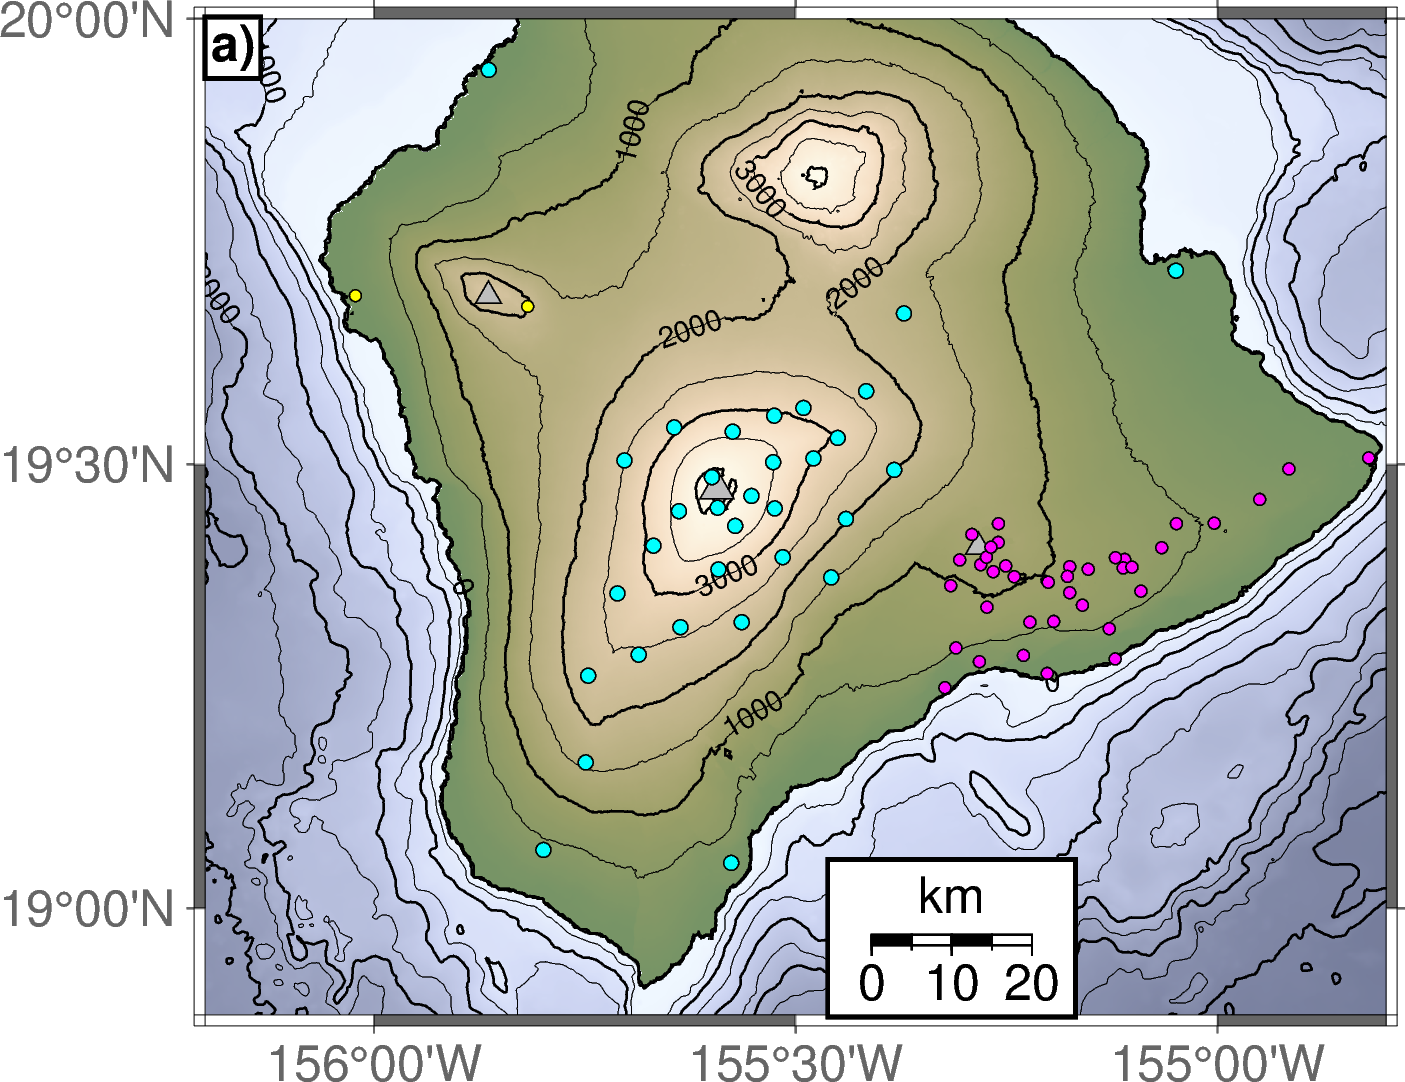

In [34]:

import pygmt
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="oleron", transparency=40)

fig.coast(shorelines="0.5p")
#Annotations every 1000, 7 p ft. 

fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')

fig.plot(
    y=19.688865,
    x=-155.864369,
    style='t0.1i',
    fill='grey',
    pen='black')

fig.plot(
    y=19.4069,
    x=-155.2834,
    style='t0.1i',
    fill='grey',
    pen='black')

fig.plot(
    y=19.4720862,
    x=-155.5933435,
    style='t0.13i',
    fill='grey',
    pen='black',
    label='Volcano')



#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])



# for i in range(0, len(df_tilt)):
#     df_tilt



fig.plot(
    y=df_GPS['Lat'].loc[df_GPS['Volcano']=='Mauna Loa'],
    x=df_GPS['Lon'].loc[df_GPS['Volcano']=='Mauna Loa'],
    style='c0.05i',
    fill='cyan',
    pen='black',
    label='ML GPS',
    )


fig.plot(
    y=df_GPS['Lat'].loc[df_GPS['Volcano']=='Kīlauea'],
    x=df_GPS['Lon'].loc[df_GPS['Volcano']=='Kīlauea'],
    style='c0.04i',
    fill='magenta',
    pen='black',
    label='K GPS',
    )

fig.plot(
    y=df_GPS['Lat'].loc[df_GPS['Volcano']=='Hualālai'],
    x=df_GPS['Lon'].loc[df_GPS['Volcano']=='Hualālai'],
    style='c0.04i',
    fill='yellow',
    pen='black',
    label='H GPS',
    )

fig.basemap(
    map_scale="jBR+w20k+f+lkm+o3c/0.5", box='+gwhite+p1p' # Adjust position (BL = bottom left), width, and label
)


fig.text(
    text="a)",  # The text to display
    position="TL",  # Top left corner
    offset="0.05c/-0.05c",  # Slightly offset from the very corner
    font="12p,Helvetica-Bold,black",  # Font settings
     pen="1p,black",
    fill="white",  # Background color of the text box
    no_clip=True  # Ensures text is not clipped at the map border
)

# Set font globally (e.g., for legends, annotations)

# fig.legend(
#     position='JBR+jBR+o0.1c/0.1c',
#     box='+gwhite+p1p'
# )
fig.savefig('MaunaLoa_GPS.png', dpi=300)
fig.show()

In [8]:
df_number=pd.DataFrame(data={'GPS_ML': sum(df_GPS['Volcano']=='Mauna Loa'),
                             'GPS_K': sum(df_GPS['Volcano']=='Kīlauea'),
                             'GPS_H': sum(df_GPS['Volcano']=='Hualālai'),
                             'Tilt_ML': sum(df_tilt['Volcano']=='Mauna Loa'),
                             'Tilt_K': sum(df_tilt['Volcano']=='Kīlauea'),
                             'Tilt_H': sum(df_tilt['Volcano']=='Hualālai'),
                             'Webcam_ML':sum(df_web['Volcano']=='Mauna Loa')   ,
                             'Webcam_K': sum(df_web['Volcano']=='Kīlauea')    ,
                             'Webcam_H': sum(df_web['Volcano']=='Hualālai') ,
                             'Infrasound_ML':sum(df_infra['Volcano']=='Mauna Loa')   ,
                             'Infrasound_K': sum(df_infra['Volcano']=='Kīlauea')    ,
                             'Infrasound_H': sum(df_infra['Volcano']=='Hualālai')    ,
                             'Gas_ML':sum(df_Gas['Volcano']=='Mauna Loa')   ,
                             'Gas_K': sum(df_Gas['Volcano']=='Kīlauea')    ,
                                'Gas_H': sum(df_Gas['Volcano']=='Hualālai')    ,
                            'Broadband_ML': sum(filt_ML_b) ,
                            'Broadband_K': sum(filt_K_b) ,
                            'Broadband_H': sum(filt_H_b) ,
                            'Short-period_ML': sum(filt_ML_s) ,
                            'Short-period_K': sum(filt_K_s) ,
                            'Short-period_H': sum(filt_H_s) ,
                             }, index=[0])

                           # 'Strong-motion_ML': sum(filt_ML_sm) ,
                            #'Strong-motion_K': sum(filt_K_sm) ,
df_number
df=df_number

In [9]:
df_number

,GPS_ML,GPS_K,GPS_H,Tilt_ML,Tilt_K,Tilt_H,Webcam_ML,Webcam_K,Webcam_H,Infrasound_ML,...,Infrasound_H,Gas_ML,Gas_K,Gas_H,Broadband_ML,Broadband_K,Broadband_H,Short-period_ML,Short-period_K,Short-period_H
0,32,38,2,6,10,0,6,13,0,1,...,1,1,17,0,10,26,2,13,11,1


In [18]:
groups

[('GPS', np.int64(32), np.int64(2), np.int64(38)),
 ('Tilt', np.int64(6), np.int64(0), np.int64(10)),
 ('Webcam', np.int64(6), np.int64(0), np.int64(13)),
 ('Infrasound', np.int64(1), np.int64(1), np.int64(3)),
 ('Gas', np.int64(1), np.int64(0), np.int64(17)),
 ('Broadband', np.int64(10), np.int64(2), np.int64(26)),
 ('Short-period', np.int64(13), np.int64(1), np.int64(11))]

In [78]:
plt.rcParams["font.family"] = 'arial'
plt.rcParams["font.size"] =14
plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "dejavusans"
plt.rcParams['patch.linewidth'] = 1
plt.rcParams['axes.linewidth'] = 1
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6 # Sets length of ticks
plt.rcParams["ytick.major.size"] = 4 # Sets length of ticks
plt.rcParams["ytick.labelsize"] = 14 # Sets size of numbers on tick marks
plt.rcParams["xtick.labelsize"] = 14 # Sets size of numbers on tick marks
plt.rcParams["axes.titlesize"] = 14 # Overall title
plt.rcParams["axes.labelsize"] = 14 # Axes labels

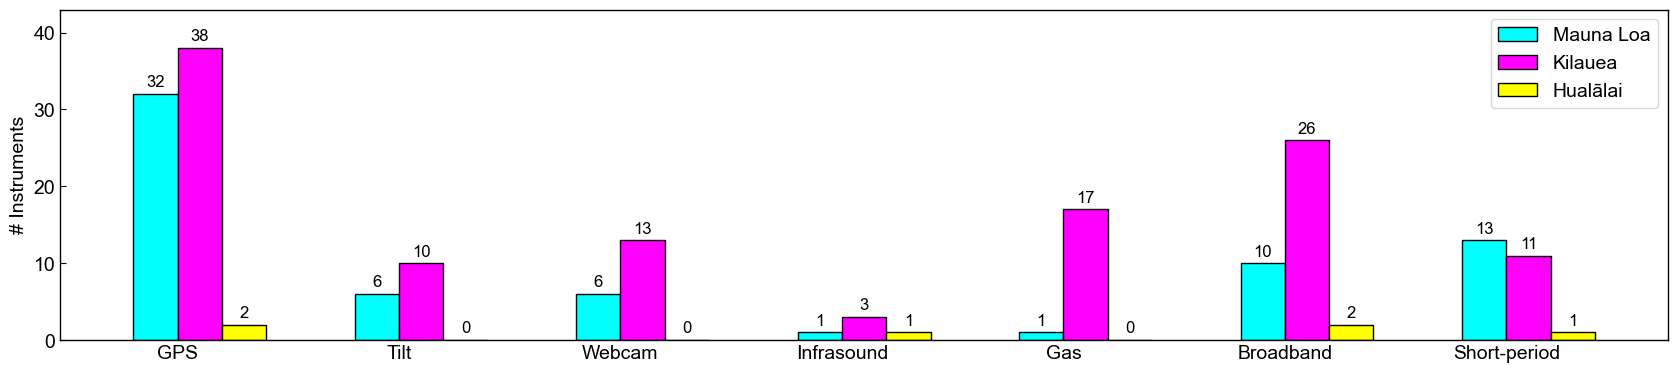

In [81]:
groups = [
    (
        col[:-3],  # base name (e.g., 'GPS')
        df[col].values[0],  # ML value
        df[col[:-3] + '_H'].values[0],  # H value
        df[col[:-3] + '_K'].values[0]   # K value
    )
    for col in df.columns
    if col.endswith('_ML')
]

# Unpack into lists for plotting or comparison
categories, values_ML, values_H, values_K = zip(*groups)
x = np.arange(len(categories))  # the label locations

# Plotting
fig, (ax) = plt.subplots(1, figsize=(17,4))
width = 0.2  # the width of the bars
rects1 = ax.bar(x - width/2, values_ML, width, color='cyan', ec='k', label='Mauna Loa')
rects2 = ax.bar(x + width/2, values_K, width, color='magenta', ec='k', label='Kilauea')
rects3 = ax.bar(x + width*1.5, values_H, width, color='yellow', ec='k', label='Hualālai')

# Adding some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('# Instruments')

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0)  # Rotate for better readability
ax.legend()


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
fig.tight_layout()
ax.set_ylim([0, 43])

fig.savefig('#instrments.png', dpi=200)

## Tilt and gravity

groups = [(col.split('_')[0], df[col+'_ML'].values[0], df[col+'_K'].values[0]) for col in df.columns if 'ML' in col]

# Preparing data for plotting
categories, values_ML, values_K = zip(*groups)
x = np.arange(len(categories))  # the label locations

# Plotting
fig, ax = plt.subplots()
width = 0.35  # the width of the bars
rects1 = ax.bar(x - width/2, values_ML, width, label='Mauna Loa')
rects2 = ax.bar(x + width/2, values_K, width, label='Kilauea')


C:\Users\penny\AppData\Local\Temp\ipykernel_6684\1045221637.py:8: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
C:\Users\penny\AppData\Local\Temp\ipykernel_6684\1045221637.py:9: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')


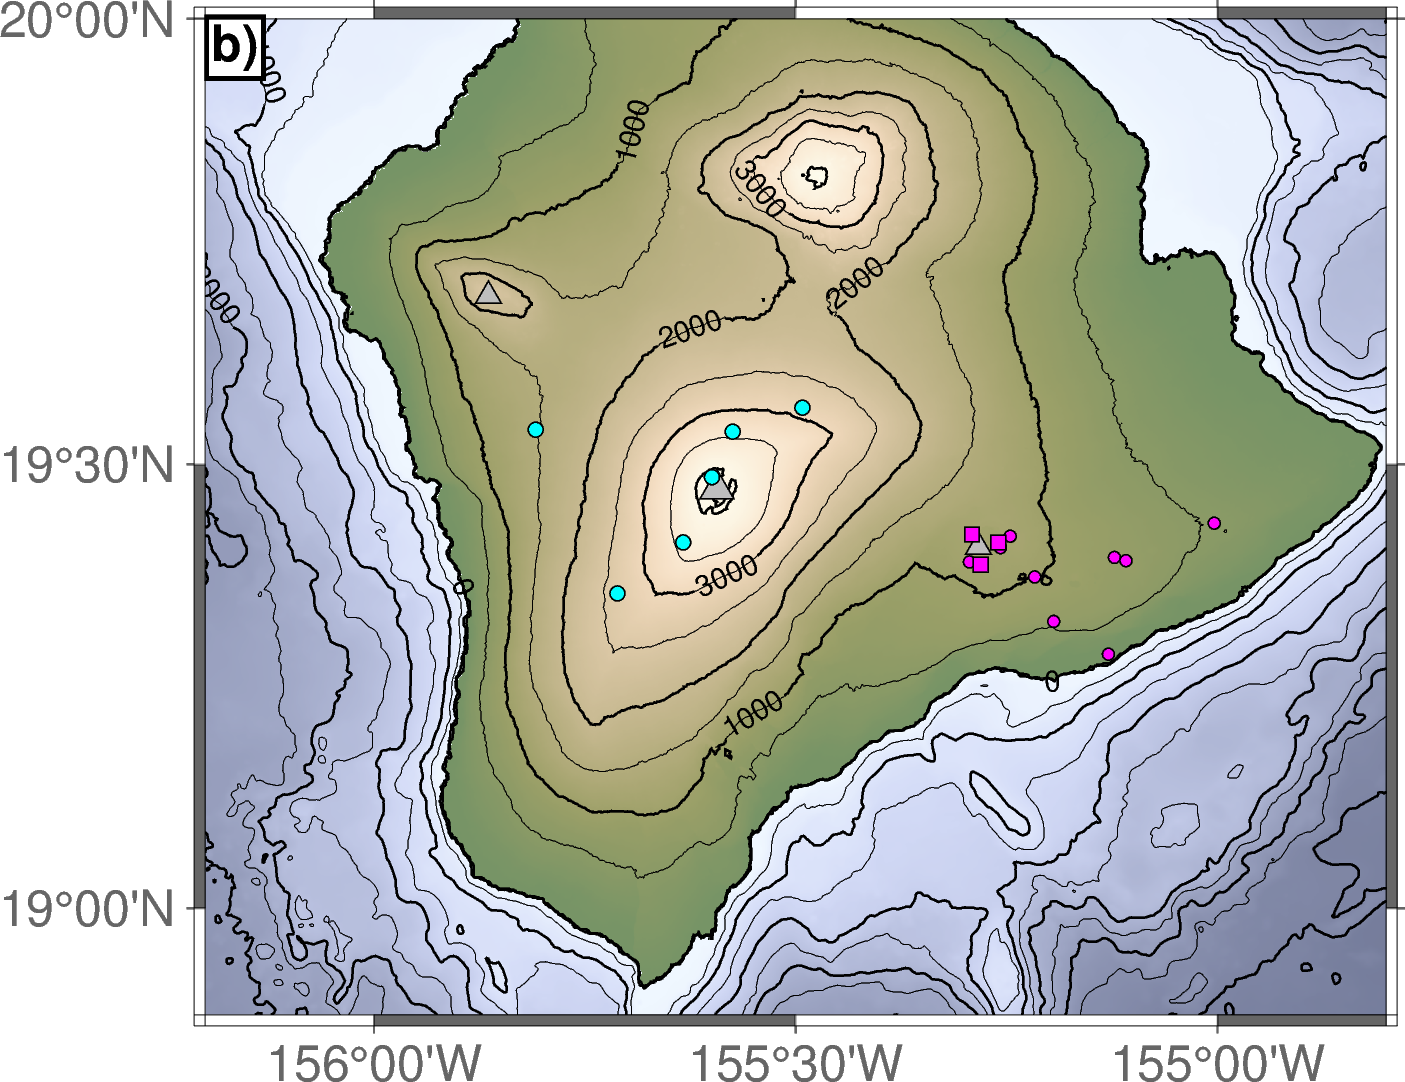

In [82]:

import pygmt
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="oleron", transparency=40)

fig.coast(shorelines="0.5p")
#Annotations every 1000, 7 p ft. 

fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')

#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])
fig.plot(
    y=19.688865,
    x=-155.864369,
    style='t0.1i',
    fill='grey',
    pen='black')


fig.plot(
    y=19.4069,
    x=-155.2834,
    style='t0.1i',
    fill='grey',
    pen='black')

fig.plot(
    y=19.4720862,
    x=-155.5933435,
    style='t0.13i',
    fill='grey',
    pen='black')

fig.plot(
    y=df_tilt['Lat'].loc[df_tilt['Volcano']=='Mauna Loa'],
    x=df_tilt['Lon'].loc[df_tilt['Volcano']=='Mauna Loa'],
    style='c0.05i',
    fill='cyan',
    pen='black',
    label='ML tilt',
    )


fig.plot(
    y=df_tilt['Lat'].loc[df_tilt['Volcano']=='Kīlauea'],
    x=df_tilt['Lon'].loc[df_tilt['Volcano']=='Kīlauea'],
    style='c0.04i',
    fill='magenta',
    pen='black',
    label='K tilt',
    )
# no tilt
# fig.plot(
#     y=df_tilt['Lat'].loc[df_tilt['Volcano']=='Hualālai'],
#     x=df_tilt['Lon'].loc[df_tilt['Volcano']=='Hualālai'],
#     style='c0.1i',
#     fill='yellow',
#     pen='black',
#     label='H tilt',
#     )

# No other gravimeters

fig.plot(
    y=df_Grav['Lat'],
    x=df_Grav['Lon'],
    style='s0.07i',
    fill='magenta',
    pen='black',
    label='K Gravimeter',
    )

fig.text(
    text="b)",  # The text to display
    position="TL",  # Top left corner
    offset="0.05c/-0.05c",  # Slightly offset from the very corner
    font="12p,Helvetica-Bold,black",  # Font settings
     pen="1p,black",
    fill="white",  # Background color of the text box
    no_clip=True  # Ensures text is not clipped at the map border
)

# fig.legend(position='JBR+jBR+o0.1c/0.1c',     box='+gwhite+p1p')
fig.savefig('MaunaLoa_grav.png', dpi=300)
fig.show()

## Seismic network

C:\Users\penny\AppData\Local\Temp\ipykernel_6684\3184846798.py:8: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
C:\Users\penny\AppData\Local\Temp\ipykernel_6684\3184846798.py:9: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')


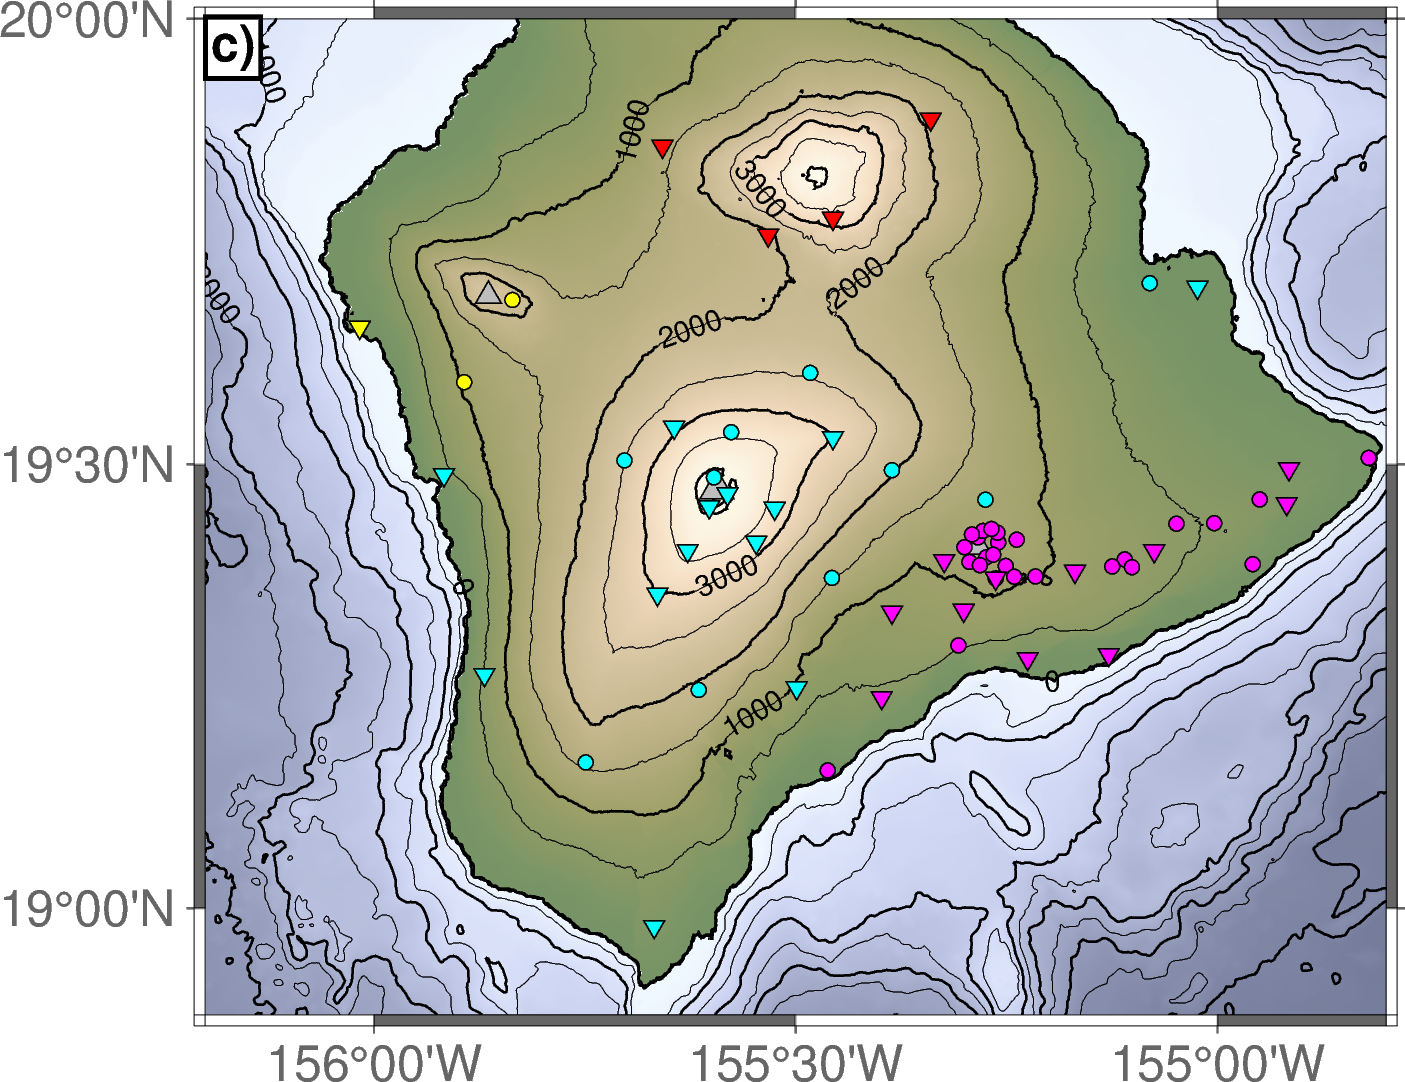

In [84]:

import pygmt
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="oleron", transparency=40)

fig.coast(shorelines="0.5p")
#Annotations every 1000, 7 p ft. 

fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')

#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])

## Volcanoes

fig.plot(
    y=19.688865,
    x=-155.864369,
    style='t0.1i',
    fill='grey',
    pen='black')


fig.plot(
    y=19.4069,
    x=-155.2834,
    style='t0.1i',
    fill='grey',
    pen='black')

fig.plot(
    y=19.4720862,
    x=-155.5933435,
    style='t0.13i',
    fill='grey',
    pen='black')





# for i in range(0, len(df_tilt)):
#     df_tilt


# fig.plot(
#     y=df_Seis['Lat'].loc[filt_ML_sm],
#     x=df_Seis['Lon'].loc[filt_ML_sm],
#     style='x0.1i',
#     fill='cyan',
#     pen="1p,cyan",
#     label='ML Strong Motion',
#     )

fig.plot(
    y=df_Seis['Lat'].loc[filt_ML_b],
    x=df_Seis['Lon'].loc[filt_ML_b],
    style='c0.05i',
    fill='cyan',
    pen='black',
    label='ML Broadband',
    )

fig.plot(
    y=df_Seis['Lat'].loc[filt_ML_s],
    x=df_Seis['Lon'].loc[filt_ML_s],
    style='i0.08i',
    fill='cyan',
    pen='black',
    label='ML Short-period',
    )





# fig.plot(
#     y=df_Seis['Lat'].loc[filt_K_sm],
#     x=df_Seis['Lon'].loc[filt_K_sm],
#     style='x0.1i',
#     fill='magenta',
#     pen="1p,magenta",
#     label='K Strong Motion',
    
#     )

fig.plot(
    y=df_Seis['Lat'].loc[filt_K_b],
    x=df_Seis['Lon'].loc[filt_K_b],
    style='c0.05i',
    fill='magenta',
    pen='black',
    label='K Broadband',
    )

fig.plot(
    y=df_Seis['Lat'].loc[filt_K_s],
    x=df_Seis['Lon'].loc[filt_K_s],
    style='i0.08i',
    fill='magenta',
    pen='black',
    label='K Short-period',
    )

## Hulailai
fig.plot(
    y=df_Seis['Lat'].loc[filt_H_s],
    x=df_Seis['Lon'].loc[filt_H_s],
    style='i0.08i',
    fill='yellow',
    pen='black',
    label='H Short-period',
    )

fig.plot(
    y=df_Seis['Lat'].loc[filt_H_b],
    x=df_Seis['Lon'].loc[filt_H_b],
    style='c0.05i',
    fill='yellow',
    pen='black',
    label='H Broadband',
    )
fig.plot(
    y=df_Seis['Lat'].loc[(df_Seis['Status']=='active') & (df_Seis['Volcano'] == '') | (df_Seis['Volcano'].isna()) & (df_Seis['Type'].str.contains('short-period'))],
    x=df_Seis['Lon'].loc[(df_Seis['Status']=='active') & (df_Seis['Volcano'] == '') | (df_Seis['Volcano'].isna()) & (df_Seis['Type'].str.contains('short-period'))],
    style='i0.08i',
    fill='red',
    pen='black',
    label='Other short-period',
    )

fig.plot(
    y=df_Seis['Lat'].loc[(df_Seis['Status']=='active') & (df_Seis['Volcano'] == '') | (df_Seis['Volcano'].isna()) & (df_Seis['Type'].str.contains('broadband'))],
    x=df_Seis['Lon'].loc[(df_Seis['Status']=='active') & (df_Seis['Volcano'] == '') | (df_Seis['Volcano'].isna()) & (df_Seis['Type'].str.contains('broadband'))],
    style='i0.08i',
    fill='red',
    pen='black',
    label='Other broadband',
    )


fig.text(
    text="c)",  # The text to display
    position="TL",  # Top left corner
    offset="0.05c/-0.05c",  # Slightly offset from the very corner
    font="12p,Helvetica-Bold,black",  # Font settings
     pen="1p,black",
    fill="white",  # Background color of the text box
    no_clip=True  # Ensures text is not clipped at the map border
)



#fig.legend(position='JBR+jBR+o0.1c/0.1c',     box='+gwhite+p1p')
fig.savefig('MaunaLoa_Seismics.png', dpi=300)
fig.show()

C:\Users\penny\AppData\Local\Temp\ipykernel_6684\939367417.py:8: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
C:\Users\penny\AppData\Local\Temp\ipykernel_6684\939367417.py:9: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')


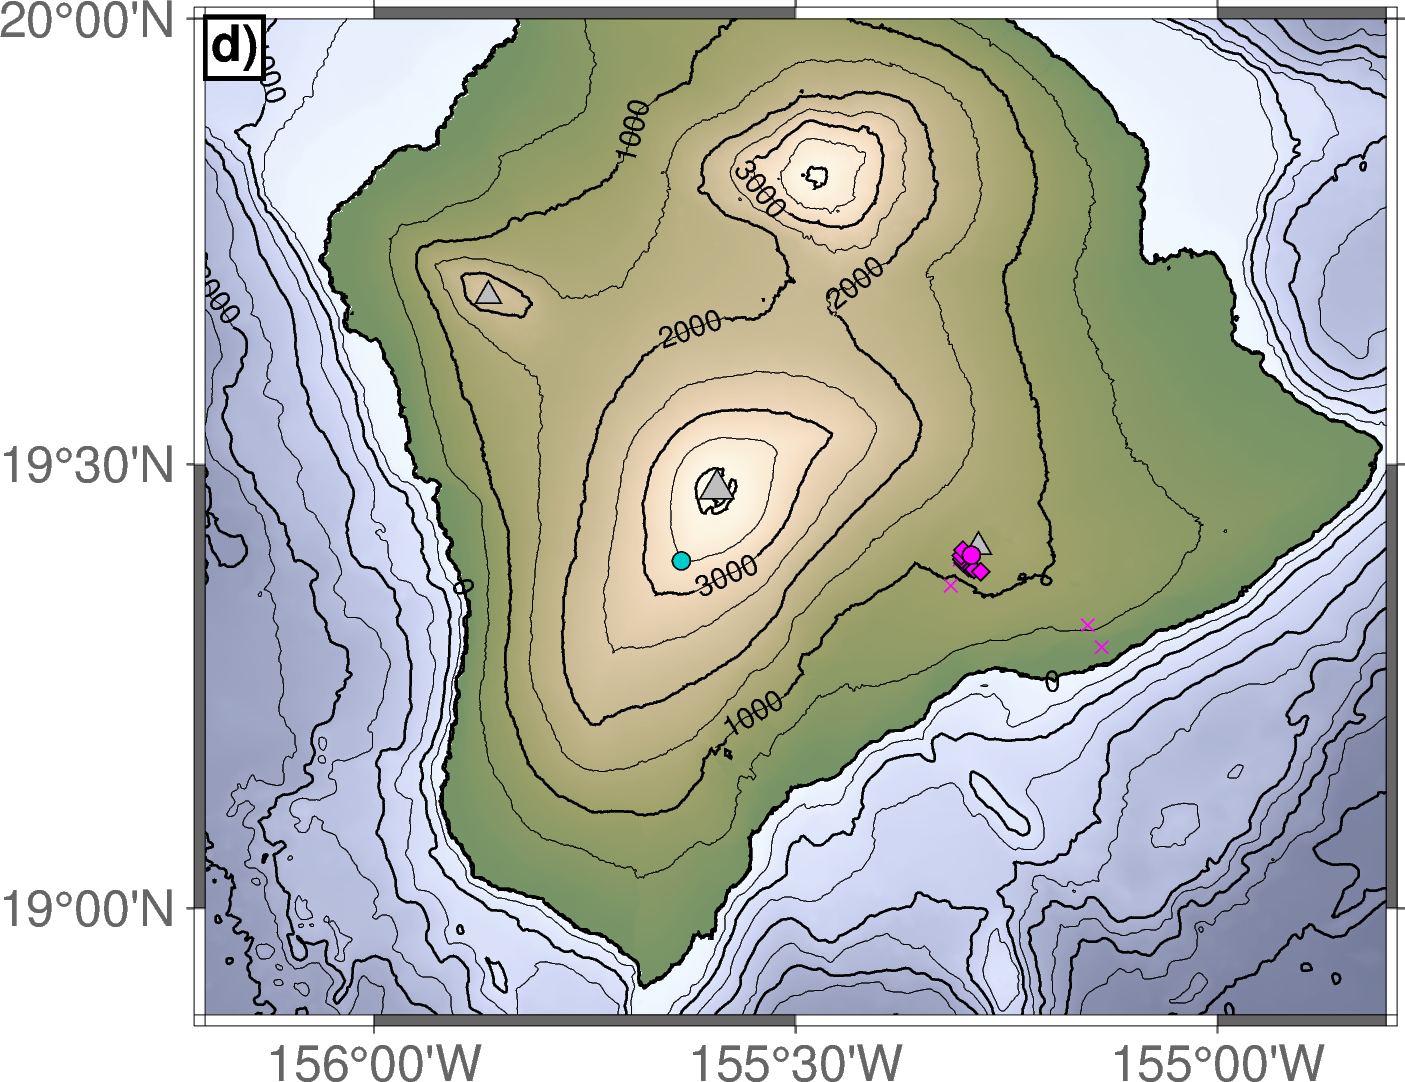

In [50]:

import pygmt
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="oleron", transparency=40)

fig.coast(shorelines="0.5p")
#Annotations every 1000, 7 p ft. 

fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')

#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])



# for i in range(0, len(df_tilt)):
#     df_tilt

## Volcanoes

fig.plot(
    y=19.688865,
    x=-155.864369,
    style='t0.1i',
    fill='grey',
    pen='black')


fig.plot(
    y=19.4069,
    x=-155.2834,
    style='t0.1i',
    fill='grey',
    pen='black')

fig.plot(
    y=19.4720862,
    x=-155.5933435,
    style='t0.13i',
    fill='grey',
    pen='black')

fig.plot(
    y=df_Gas['Lat'].loc[(df_Gas['Volcano']=='Mauna Loa') & (df_Gas['Type']=='gas continuous (multigas)')],
    x=df_Gas['Lon'].loc[(df_Gas['Volcano']=='Mauna Loa')& (df_Gas['Type']=='gas continuous (multigas)')],
    style='c0.06i',
    fill='cyan3',
    pen='black',
    label='ML Gas',
    )


# fig.plot(
#     y=df_Gas['Lat'].loc[(df_Gas['Volcano']=='Mauna Loa') & (df_Gas['Type']=='gas continuous (high-resolution)') ],
#     x=df_Gas['Lon'].loc[(df_Gas['Volcano']=='Mauna Loa')& (df_Gas['Type']=='gas continuous (high-resolution)')],
#     style='s0.06i',
#     fill='cyan3',
#     pen='black',
#     label='ML Gas',
#     )



fig.plot(
    y=df_Gas['Lat'].loc[(df_Gas['Volcano']=='Kīlauea')& (df_Gas['Type']=='gas continuous (high-resolution)') ],
    x=df_Gas['Lon'].loc[(df_Gas['Volcano']=='Kīlauea')& (df_Gas['Type']=='gas continuous (high-resolution)') ],
    style='x0.06i',
    fill='magenta',
    pen='black',
    label='K Gas',
    )


fig.plot(
    y=df_Gas['Lat'].loc[(df_Gas['Volcano']=='Kīlauea')& (df_Gas['Type']=='gas continuous (FLYSPEC)') ],
    x=df_Gas['Lon'].loc[(df_Gas['Volcano']=='Kīlauea')& (df_Gas['Type']=='gas continuous (FLYSPEC)') ],
    style='d0.06i',
    fill='magenta',
    pen='black',
    label='K Gas',
    )

fig.plot(
    y=df_Gas['Lat'].loc[(df_Gas['Volcano']=='Kīlauea') & (df_Gas['Type']=='gas continuous (multigas)')],
    x=df_Gas['Lon'].loc[(df_Gas['Volcano']=='Kīlauea')& (df_Gas['Type']=='gas continuous (multigas)')],
    style='c0.06i',
    fill='magenta',
    pen='black',
    label='K Gas',
    )

fig.text(
    text="d)",  # The text to display
    position="TL",  # Top left corner
    offset="0.05c/-0.05c",  # Slightly offset from the very corner
    font="12p,Helvetica-Bold,black",  # Font settings
     pen="1p,black",
    fill="white",  # Background color of the text box
    no_clip=True  # Ensures text is not clipped at the map border
)

#fig.legend(position='JBR+jBR+o0.1c/0.1c',     box='+gwhite+p1p')
fig.savefig('MaunaLoa_Gas.png', dpi=300)
fig.show()

C:\Users\penny\AppData\Local\Temp\ipykernel_6684\94004490.py:8: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
C:\Users\penny\AppData\Local\Temp\ipykernel_6684\94004490.py:9: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')


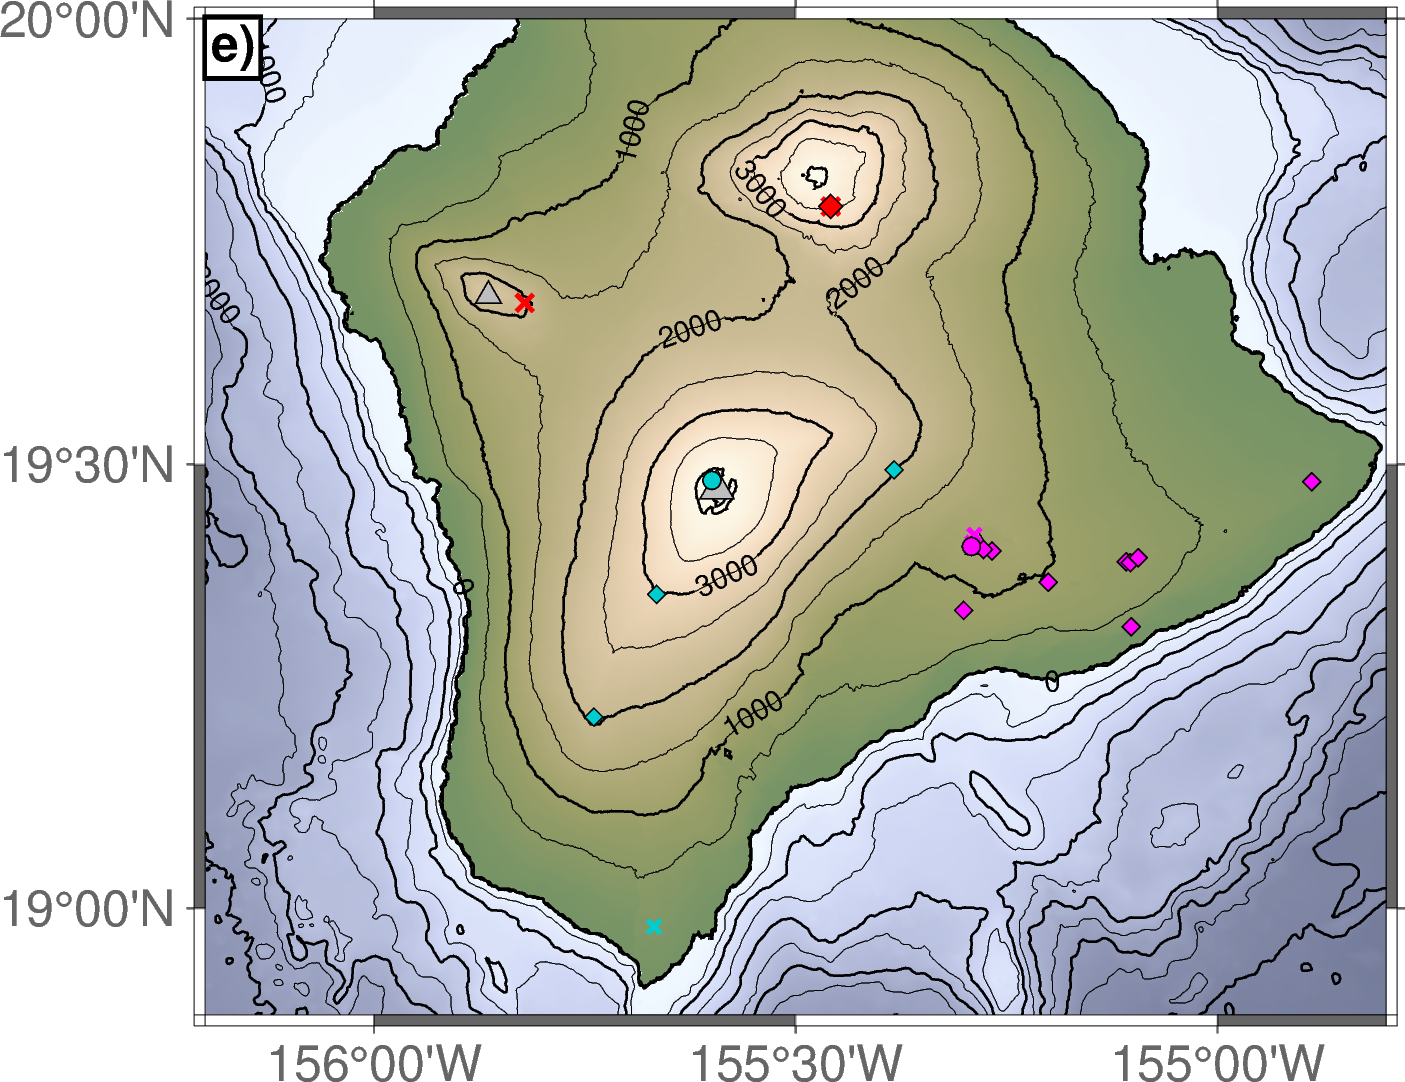

In [74]:

import pygmt
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="oleron", transparency=40)

fig.coast(shorelines="0.5p")
#Annotations every 1000, 7 p ft. 

fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')

#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])

fig.plot(
    y=19.688865,
    x=-155.864369,
    style='t0.1i',
    fill='grey',
    pen='black')


fig.plot(
    y=19.4069,
    x=-155.2834,
    style='t0.1i',
    fill='grey',
    pen='black')

fig.plot(
    y=19.4720862,
    x=-155.5933435,
    style='t0.13i',
    fill='grey',
    pen='black')

# for i in range(0, len(df_tilt)):
#     df_tilt


PTZ=df_web['Type'].str.contains('PTZ')
Thermal=df_web['Type'].str.contains('thermal')
Other= ~(PTZ | Thermal)
OtherVolc=(df_web['Volcano'] == '') | (df_web['Volcano'].isna()) 


#
# fig.plot(
#     y=df_web['Lat'].loc[OtherVolc&Thermal],
#     x=df_web['Lon'].loc[OtherVolc&Thermal],
#     style='c0.06i',
#     fill='red',
#     pen='black',
#     label='other thermal Webcam',
#     )
 
 ## Pan Zoom Tilt ones
 ## Thermal ones
fig.plot(
    y=df_web['Lat'].loc[(df_web['Volcano']=='Mauna Loa')&PTZ],
    x=df_web['Lon'].loc[(df_web['Volcano']=='Mauna Loa')&PTZ],
    style='x0.06i',
    fill='cyan3',
    pen='1p, black',
    label='ML PZT webcam',
    )



fig.plot(
    y=df_web['Lat'].loc[OtherVolc&PTZ],
    x=df_web['Lon'].loc[OtherVolc&PTZ],
    style='x0.08i',
    fill='red',
    pen='1p, black',
    label='other PZT Webcam',
    )

fig.plot(
    y=df_web['Lat'].loc[(df_web['Volcano']=='Kīlauea')&PTZ],
    x=df_web['Lon'].loc[(df_web['Volcano']=='Kīlauea')&PTZ],
    style='x0.06i',
    fill='magenta',
    pen='1p, black',
    label='K PZT Webcam',
    )



fig.text(
    text="e)",  # The text to display
    position="TL",  # Top left corner
    offset="0.05c/-0.05c",  # Slightly offset from the very corner
    font="12p,Helvetica-Bold,black",  # Font settings
     pen="1p,black",
    fill="white",  # Background color of the text box
    no_clip=True  # Ensures text is not clipped at the map border
)

## Traditional webcam 
fig.plot(
    y=df_web['Lat'].loc[OtherVolc&Other],
    x=df_web['Lon'].loc[OtherVolc&Other],
    style='d0.08i',
    fill='red',
    pen='black',
    label='other Webcam',
    )

fig.plot(
    y=df_web['Lat'].loc[(df_web['Volcano']=='Kīlauea')&Other],
    x=df_web['Lon'].loc[(df_web['Volcano']=='Kīlauea')&Other],
    style='d0.06i',
    fill='magenta',
    pen='black',
    label='K Webcam',
    )

fig.plot(
    y=df_web['Lat'].loc[(df_web['Volcano']=='Mauna Loa')&Other],
    x=df_web['Lon'].loc[(df_web['Volcano']=='Mauna Loa')&Other],
    style='d0.06i',
    fill='cyan3',
    pen='black',
    label='ML  webcam',
    )

## LETs put thermal ontop
# Thermal ones
fig.plot(
    y=df_web['Lat'].loc[(df_web['Volcano']=='Mauna Loa')&Thermal],
    x=df_web['Lon'].loc[(df_web['Volcano']=='Mauna Loa')&Thermal],
    style='c0.06i',
    fill='cyan3',
    pen='black',
    label='ML thermal webcam',
    )



fig.plot(
    y=df_web['Lat'].loc[(df_web['Volcano']=='Kīlauea')&Thermal],
    x=df_web['Lon'].loc[(df_web['Volcano']=='Kīlauea')&Thermal],
    style='c0.06i',
    fill='magenta',
    pen='black',
    label='K thermal Webcam',
    )


#fig.legend(position='JBR+jBR+o0.1c/0.1c',     box='+gwhite+p1p')
fig.savefig('MaunaLoa_Web.png', dpi=300)
fig.show()

In [69]:
df_web['Lat'].loc[(df_web['Volcano']=='Mauna Loa')&PTZ]

24    18.97931
Name: Lat, dtype: float64

C:\Users\penny\AppData\Local\Temp\ipykernel_6684\2496738468.py:8: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
C:\Users\penny\AppData\Local\Temp\ipykernel_6684\2496738468.py:9: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')


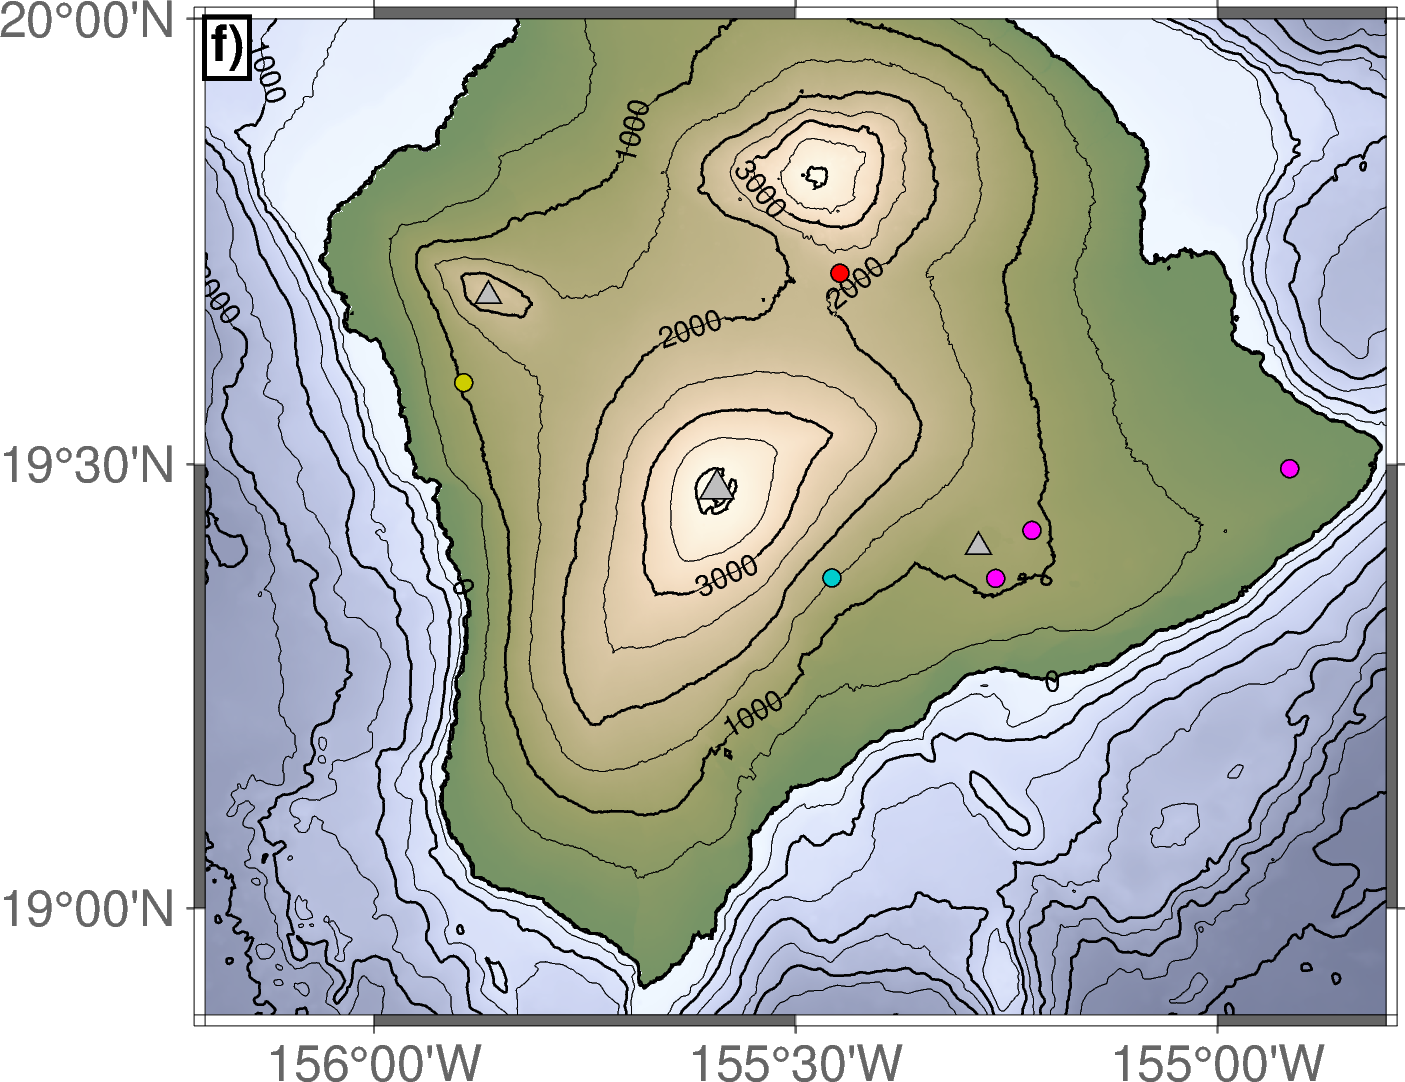

In [77]:

import pygmt
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="oleron", transparency=40)

fig.coast(shorelines="0.5p")
#Annotations every 1000, 7 p ft. 

fig.grdcontour(grid=grid, interval=500,  pen='0.1p')
fig.grdcontour(grid=grid, interval=1000, annotation='1000+f7p', pen='0.5p')

#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])

fig.plot(
    y=19.688865,
    x=-155.864369,
    style='t0.1i',
    fill='grey',
    pen='black')


fig.plot(
    y=19.4069,
    x=-155.2834,
    style='t0.1i',
    fill='grey',
    pen='black')

fig.plot(
    y=19.4720862,
    x=-155.5933435,
    style='t0.13i',
    fill='grey',
    pen='black')

# for i in range(0, len(df_tilt)):
#     df_tilt

OtherVolc=(df_infra['Volcano'] == '') | (df_infra['Volcano'].isna()) 
fig.plot(
    y=df_infra['Lat'].loc[OtherVolc],
    x=df_infra['Lon'].loc[OtherVolc],
    style='c0.06i',
    fill='red',
    pen='black',
    label='ML infrasound',
    )

fig.plot(
    y=df_infra['Lat'].loc[df_infra['Volcano']=='Mauna Loa'],
    x=df_infra['Lon'].loc[df_infra['Volcano']=='Mauna Loa'],
    style='c0.06i',
    fill='cyan3',
    pen='black',
    label='ML infrasound',
    )


fig.plot(
    y=df_infra['Lat'].loc[df_infra['Volcano']=='Hualālai'],
    x=df_infra['Lon'].loc[df_infra['Volcano']=='Hualālai'],
    style='c0.06i',
    fill='yellow3',
    pen='black',
    label='ML infrasound',
    )

fig.plot(
    y=df_infra['Lat'].loc[df_infra['Volcano']=='Kīlauea'],
    x=df_infra['Lon'].loc[df_infra['Volcano']=='Kīlauea'],
    style='c0.06i',
    fill='magenta',
    pen='black',
    label='K infrasound',
    )

fig.text(
    text="f)",  # The text to display
    position="TL",  # Top left corner
    offset="0.05c/-0.05c",  # Slightly offset from the very corner
    font="12p,Helvetica-Bold,black",  # Font settings
     pen="1p,black",
    fill="white",  # Background color of the text box
    no_clip=True  # Ensures text is not clipped at the map border
)


#fig.legend(position='JBR+jBR+o0.1c/0.1c',     box='+gwhite+p1p')
fig.savefig('MaunaLoa_infra.png', dpi=300)
fig.show()

In [16]:
df_tilt['Lon'].iloc[0]

np.float64(-155.599373)

In [17]:
df_tilt['Lat'].iloc[0]

np.float64(19.485347)